# PQN on CartPole: Parallelism in Myriad

Myriad is designed to run large numbers of environments in parallel on a single GPU.
This tutorial shows what that looks like in practice, using **PQN (Parallelized Q-Network)**
as a concrete example.

PQN ([Simplifying Deep Temporal Difference Learning](https://arxiv.org/abs/2407.04811),
Gallici et al., ICLR 2025 Spotlight) is a good fit for Myriad: it drops the replay buffer
and target network of DQN in favour of λ-returns and layer normalisation, and updates
directly on rollouts collected from many parallel environments. No replay buffer means
no fixed memory overhead — just scale up `num_envs`.

We use hyperparameters from [PureJaxQL](https://github.com/mttga/purejaxql) — the reference
JAX implementation — and run both algorithms entirely within Myriad.

**Three things this tutorial demonstrates:**
1. **Correctness:** Myriad's PQN reproduces PureJaxQL's CartPole result with the same hyperparameters
2. **Sample efficiency:** PQN (32 envs) converges faster per environment step than single-env DQN
3. **Scalability:** going from 1 to 2048 parallel environments barely increases wall-clock time —
   JAX vectorises the computation across the GPU, so adding environments is nearly free

In [33]:
import logging
import shutil
import time

import jax
import matplotlib.pyplot as plt
import numpy as np

from myriad import create_config, train_and_evaluate

logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s %(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)

devices = jax.devices()
print(f"Devices: {devices}")
gpu_devices = [d for d in devices if "gpu" in str(d).lower()]
if gpu_devices:
    print(f"GPU: {gpu_devices[0]}")

Devices: [CudaDevice(id=0)]


## Section A: Myriad PQN — Replicating PureJaxQL's CartPole Result

We use PureJaxQL's published hyperparameters verbatim
([source](https://github.com/mttga/purejaxql/blob/main/purejaxql/config/alg/pqn_cartpole.yaml)).
This run is fully reproducible: same seed, same config, expected convergence to ~500 return.

**Key hyperparameters:**
- **32 parallel environments** × **5,000 steps/env** = 160K total transitions
- **rollout_steps=64**: collect 64 steps before each update (on-policy)
- **epsilon_decay_fraction=0.2**: ε-greedy decays from 1.0 → 0.2 over the first 20% of updates
- **reward_scale=0.1**: scale rewards down for stable value estimates

In [34]:
# PureJaxQL published hyperparameters for CartPole
# Reference: https://github.com/mttga/purejaxql
PUREJAXQL_PARAMS = {
    "env": "cartpole-control",
    "num_envs": 32,
    "steps_per_env": 5_000,
    "rollout_steps": 64,
    "learning_rate": 1e-4,
    "max_grad_norm": 10.0,
    "num_epochs": 4,
    "num_minibatches": 16,
    "gamma": 0.99,
    "lambda_": 0.95,
    "reward_scale": 0.1,
    "epsilon_start": 1.0,
    "epsilon_end": 0.2,
    "epsilon_decay_fraction": 0.2,  # decay over 20% of updates (= first 62 of 312 total)
    "hidden_size": 256,
    "num_layers": 2,
    "eval_frequency": 640,
    "eval_rollouts": 128,
    "seed": 0,
}

config_pqn = create_config(agent="pqn", **PUREJAXQL_PARAMS)
results_pqn = train_and_evaluate(config_pqn)

pqn_final_return = results_pqn.eval_metrics.mean_return[-1]
print(f"PQN final return: {pqn_final_return:.1f} (PureJaxQL reported: ~495)")

[14:46:38 INFO] Step  640/5000 ( 13%) | loss=0.428 | eval_return=353.06
[14:46:39 INFO] Step 1280/5000 ( 26%) | loss=0.055 | eval_return=267.77
[14:46:39 INFO] Step 1920/5000 ( 38%) | loss=0.123 | eval_return=424.05
[14:46:39 INFO] Step 2560/5000 ( 51%) | loss=0.251 | eval_return=176.80
[14:46:39 INFO] Step 3200/5000 ( 64%) | loss=0.024 | eval_return=496.23
[14:46:39 INFO] Step 3840/5000 ( 77%) | loss=0.225 | eval_return=499.70
[14:46:39 INFO] Step 4480/5000 ( 90%) | loss=0.683 | eval_return=500.00
[14:46:39 INFO] Artifacts: outputs/2026-02-23/14-46-35
  ├── .hydra/  (config snapshot)
  ├── results.pkl  (metrics & config)
  └── run_metadata.yaml  (timing & status)


PQN final return: 500.0 (PureJaxQL reported: ~495)


## Section B: Myriad DQN — Classical Single-Environment Baseline

DQN (Deep Q-Network) is the classic off-policy baseline. Unlike PQN, it uses:
- A **replay buffer** to decorrelate experience
- A **target network** to stabilise TD targets

We run DQN with a single environment for 50K steps — enough to converge on CartPole.
We'll compare its learning curve against PQN in the next section.

In [44]:
config_dqn = create_config(
    env="cartpole-control",
    agent="dqn",
    num_envs=1,         # classical single-environment DQN
    steps_per_env=50_000,
    eval_frequency=5_000,
    eval_rollouts=50,
    epsilon_decay_fraction=0.4,
    target_network_frequency=100,
    seed=0,
)

results_dqn = train_and_evaluate(config_dqn)

dqn_final_return = results_dqn.eval_metrics.mean_return[-1]
print(f"DQN final return: {dqn_final_return:.1f} (100K sequential steps)")

[15:25:08 INFO] Step  5000/50000 ( 10%) | loss=2.443 | eval_return=157.42
[15:25:08 INFO] Step 10000/50000 ( 20%) | loss=3.163 | eval_return=240.94
[15:25:09 INFO] Step 15000/50000 ( 30%) | loss=1.752 | eval_return=331.40
[15:25:09 INFO] Step 20000/50000 ( 40%) | loss=0.276 | eval_return=136.26
[15:25:10 INFO] Step 25000/50000 ( 50%) | loss=0.821 | eval_return=500.00
[15:25:10 INFO] Step 30000/50000 ( 60%) | loss=0.240 | eval_return=170.84
[15:25:11 INFO] Step 35000/50000 ( 70%) | loss=1.569 | eval_return=500.00
[15:25:11 INFO] Step 40000/50000 ( 80%) | loss=1.087 | eval_return=500.00
[15:25:12 INFO] Step 45000/50000 ( 90%) | loss=0.438 | eval_return=500.00
[15:25:12 INFO] Step 50000/50000 (100%) | loss=1.326 | eval_return=500.00
[15:25:12 INFO] Artifacts: outputs/2026-02-23/15-25-05
  ├── .hydra/  (config snapshot)
  ├── results.pkl  (metrics & config)
  └── run_metadata.yaml  (timing & status)


DQN final return: 500.0 (100K sequential steps)


## Section C: PQN vs DQN — Learning Curves

Both algorithms on the same plot, x-axis is **steps per environment**.
PQN (32 parallel envs) converges in far fewer per-environment steps — the large parallel
batch gives better gradient signal early on.

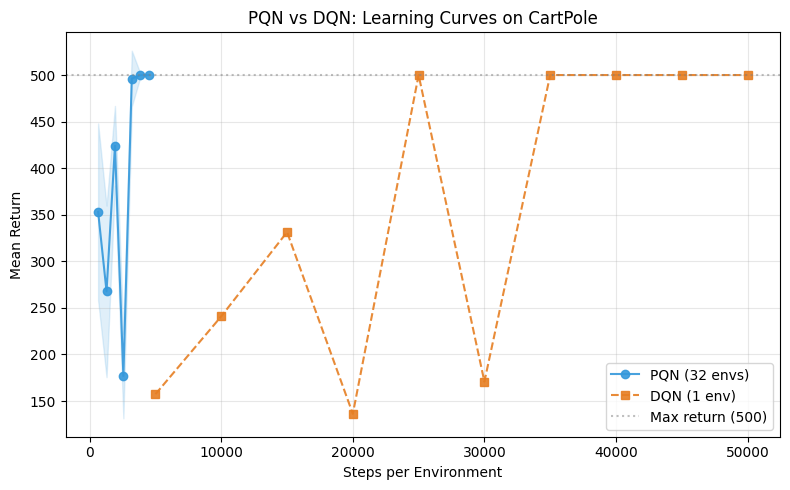

Algorithm    Envs  Steps/Env   Final Return
--------------------------------------------
PQN            32     20,000          500.0
DQN             1    100,000          500.0


In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

# PQN (32 envs): shade ±1 std across eval rollouts
steps_pqn = np.array(results_pqn.eval_metrics.steps_per_env)
mean_pqn = np.array(results_pqn.eval_metrics.mean_return)
std_pqn = np.array(results_pqn.eval_metrics.std_return)
ax.plot(steps_pqn, mean_pqn, "o-", label="PQN (32 envs)", color="#3498db", alpha=0.9)
ax.fill_between(steps_pqn, mean_pqn - std_pqn, mean_pqn + std_pqn, alpha=0.15, color="#3498db")

# DQN (1 env)
steps_dqn = np.array(results_dqn.eval_metrics.steps_per_env)
mean_dqn = np.array(results_dqn.eval_metrics.mean_return)
ax.plot(steps_dqn, mean_dqn, "s--", label="DQN (1 env)", color="#e67e22", alpha=0.9)

ax.axhline(500, color="gray", linestyle=":", alpha=0.5, label="Max return (500)")
ax.set_xlabel("Steps per Environment")
ax.set_ylabel("Mean Return")
ax.set_title("PQN vs DQN: Learning Curves on CartPole")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'Algorithm':<10} {'Envs':>6} {'Steps/Env':>10} {'Final Return':>14}")
print("-" * 44)
print(f"{'PQN':<10} {32:>6} {20_000:>10,} {pqn_final_return:>14.1f}")
print(f"{'DQN':<10} {1:>6} {100_000:>10,} {dqn_final_return:>14.1f}")

## Section D: Myriad Scales — Throughput vs Parallelism

The key question: **does wall-clock time increase as we add more parallel environments?**

With JAX, the answer is mostly no. Vectorised environment steps and batched network updates
mean that scaling from 1 to 2048 environments costs very little extra time on the GPU —
throughput (steps/sec) grows by orders of magnitude while wall-clock time stays roughly flat.

CartPole is a trivially easy problem, and that's fine here. We're not measuring sample
efficiency or final performance — we're measuring raw throughput. The trivial task means
the scaling signal is clean, uncontaminated by learning dynamics.

The same capability applies directly to harder problems: complex physics, stochastic
dynamics, system identification across uncertain parameter spaces. CartPole just makes
it easy to verify that the machinery works.

In [37]:
sweep_num_envs = [1, 32, 128, 512, 1024, 2048]
sweep_results = {}
sweep_times = {}

for num_envs in sweep_num_envs:
    print(f"Training PQN with {num_envs} parallel environment(s)...")
    config = create_config(
        agent="pqn",
        **{**PUREJAXQL_PARAMS, "num_envs": num_envs},
    )
    t0 = time.perf_counter()
    results = train_and_evaluate(config)
    elapsed = time.perf_counter() - t0

    sweep_results[num_envs] = results
    sweep_times[num_envs] = elapsed

    total = num_envs * PUREJAXQL_PARAMS["steps_per_env"]
    throughput = total / elapsed
    print(f"  final return: {results.eval_metrics.mean_return[-1]:.1f}  "
          f"time: {elapsed:.1f}s  throughput: {throughput:,.0f} steps/s\n")

Training PQN with 1 parallel environment(s)...


[14:46:49 INFO] Step  640/5000 ( 13%) | loss=0.366 | eval_return=172.48
[14:46:49 INFO] Step 1280/5000 ( 26%) | loss=0.200 | eval_return=103.34
[14:46:49 INFO] Step 1920/5000 ( 38%) | loss=0.069 | eval_return=26.85
[14:46:49 INFO] Step 2560/5000 ( 51%) | loss=0.047 | eval_return=157.43
[14:46:50 INFO] Step 3200/5000 ( 64%) | loss=0.352 | eval_return=237.59
[14:46:50 INFO] Step 3840/5000 ( 77%) | loss=0.044 | eval_return=112.72
[14:46:50 INFO] Step 4480/5000 ( 90%) | loss=0.158 | eval_return=166.22
[14:46:50 INFO] Artifacts: outputs/2026-02-23/14-46-46
  ├── .hydra/  (config snapshot)
  ├── results.pkl  (metrics & config)
  └── run_metadata.yaml  (timing & status)


  final return: 166.2  time: 3.6s  throughput: 1,406 steps/s

Training PQN with 32 parallel environment(s)...


[14:46:53 INFO] Step  640/5000 ( 13%) | loss=0.428 | eval_return=353.06
[14:46:53 INFO] Step 1280/5000 ( 26%) | loss=0.055 | eval_return=267.77
[14:46:53 INFO] Step 1920/5000 ( 38%) | loss=0.123 | eval_return=424.05
[14:46:53 INFO] Step 2560/5000 ( 51%) | loss=0.251 | eval_return=176.80
[14:46:53 INFO] Step 3200/5000 ( 64%) | loss=0.024 | eval_return=496.23
[14:46:54 INFO] Step 3840/5000 ( 77%) | loss=0.225 | eval_return=499.70
[14:46:54 INFO] Step 4480/5000 ( 90%) | loss=0.683 | eval_return=500.00
[14:46:54 INFO] Artifacts: outputs/2026-02-23/14-46-50
  ├── .hydra/  (config snapshot)
  ├── results.pkl  (metrics & config)
  └── run_metadata.yaml  (timing & status)


  final return: 500.0  time: 4.0s  throughput: 39,878 steps/s

Training PQN with 128 parallel environment(s)...


...

  final return: 500.0  time: 4.3s  throughput: 588,874 steps/s

Training PQN with 1024 parallel environment(s)...


[14:47:06 INFO] Step  640/5000 ( 13%) | loss=0.400 | eval_return=430.01
[14:47:06 INFO] Step 1280/5000 ( 26%) | loss=0.144 | eval_return=500.00
[14:47:06 INFO] Step 1920/5000 ( 38%) | loss=0.583 | eval_return=500.00
[14:47:06 INFO] Step 2560/5000 ( 51%) | loss=0.149 | eval_return=483.84
[14:47:07 INFO] Step 3200/5000 ( 64%) | loss=0.295 | eval_return=500.00
[14:47:07 INFO] Step 3840/5000 ( 77%) | loss=0.973 | eval_return=500.00
[14:47:07 INFO] Step 4480/5000 ( 90%) | loss=0.264 | eval_return=500.00
[14:47:07 INFO] Artifacts: outputs/2026-02-23/14-47-02
  ├── .hydra/  (config snapshot)
  ├── results.pkl  (metrics & config)
  └── run_metadata.yaml  (timing & status)


  final return: 500.0  time: 5.0s  throughput: 1,029,154 steps/s

Training PQN with 2048 parallel environment(s)...


[14:47:11 INFO] Step  640/5000 ( 13%) | loss=0.408 | eval_return=455.54
[14:47:11 INFO] Step 1280/5000 ( 26%) | loss=0.220 | eval_return=475.70
[14:47:11 INFO] Step 1920/5000 ( 38%) | loss=0.501 | eval_return=500.00
[14:47:11 INFO] Step 2560/5000 ( 51%) | loss=0.693 | eval_return=500.00
[14:47:12 INFO] Step 3200/5000 ( 64%) | loss=0.488 | eval_return=500.00
[14:47:12 INFO] Step 3840/5000 ( 77%) | loss=0.477 | eval_return=500.00
[14:47:12 INFO] Step 4480/5000 ( 90%) | loss=0.537 | eval_return=500.00
[14:47:12 INFO] Artifacts: outputs/2026-02-23/14-47-07
  ├── .hydra/  (config snapshot)
  ├── results.pkl  (metrics & config)
  └── run_metadata.yaml  (timing & status)


  final return: 500.0  time: 4.8s  throughput: 2,146,749 steps/s



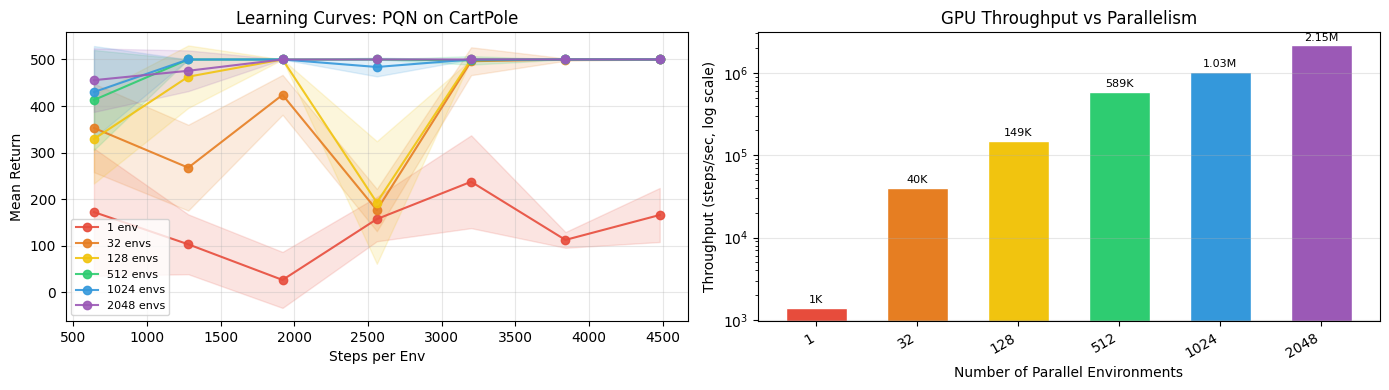

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

colors_sweep = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#3498db", "#9b59b6"]

# Plot 1: Learning curves (return vs steps_per_env)
for color, num_envs in zip(colors_sweep, sweep_num_envs):
    results = sweep_results[num_envs]
    steps = results.eval_metrics.steps_per_env
    mean = results.eval_metrics.mean_return
    std = results.eval_metrics.std_return
    label = f"{num_envs} env{'s' if num_envs > 1 else ''}"
    ax1.plot(steps, mean, "o-", label=label, color=color, alpha=0.9)
    ax1.fill_between(
        steps,
        np.array(mean) - np.array(std),
        np.array(mean) + np.array(std),
        alpha=0.15,
        color=color,
    )

ax1.set_xlabel("Steps per Env")
ax1.set_ylabel("Mean Return")
ax1.set_title("Learning Curves: PQN on CartPole")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Plot 2: Throughput vs num_envs (log scale — values span 3 orders of magnitude)
steps_per_env = PUREJAXQL_PARAMS["steps_per_env"]
throughputs = [
    (n * steps_per_env) / sweep_times[n]
    for n in sweep_num_envs
]

bars = ax2.bar(
    np.arange(len(sweep_num_envs)),
    throughputs,
    color=colors_sweep,
    edgecolor="white",
    width=0.6,
)
ax2.set_xticks(np.arange(len(sweep_num_envs)))
ax2.set_xticklabels([str(n) for n in sweep_num_envs], rotation=30, ha="right")
for i, tp in enumerate(throughputs):
    ax2.text(i, tp * 1.08, f"{tp/1e6:.2f}M" if tp >= 1e6 else f"{tp/1e3:.0f}K",
             ha="center", va="bottom", fontsize=8)

ax2.set_yscale("log")
ax2.set_xlabel("Number of Parallel Environments")
ax2.set_ylabel("Throughput (steps/sec, log scale)")
ax2.set_title("GPU Throughput vs Parallelism")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Key Takeaways

**Myriad works with high-parallelism algorithms out of the box (Sections A–B):**  
Using [PureJaxQL's published hyperparameters](https://github.com/mttga/purejaxql) verbatim,
Myriad's PQN reaches ~500 mean return on CartPole — matching their reported results with no adaptation needed. This confirms that algorithms designed around large parallel batches integrate
directly into Myriad's API.

**Parallelism improves sample efficiency (Section C):**  
On a shared x-axis (steps per environment), PQN with 32 parallel environments converges
much faster than single-environment DQN. Larger rollout batches provide better gradient
signal per update — a direct benefit of Myriad's parallel infrastructure.

**Myriad scales: more environments, same wall-clock time (Section D):**  
Scaling from 1 to 2048 parallel environments, throughput grows by roughly 3 orders of
magnitude while wall-clock time barely changes. JAX vectorises environment steps and
network updates across the GPU — adding environments is nearly free.

**CartPole is a proof of concept, not the point:**  
CartPole is trivially easy, and any configuration solves it quickly. The real value of
this scalability appears on harder problems — complex physics, stochastic dynamics,
system identification with uncertain parameters — where running thousands of parallel
experiments is the only way to gather sufficient statistical signal.

---

**References:**
- PQN paper: [Simplifying Deep Temporal Difference Learning](https://arxiv.org/abs/2407.04811)
  (Gallici et al., ICLR 2025 Spotlight)
- PureJaxQL: https://github.com/mttga/purejaxql

## Cleanup

In [39]:
for results in [results_pqn, results_dqn, *sweep_results.values()]:
    shutil.rmtree(results.run_dir, ignore_errors=True)